# TD 4 | Étude des vibrations des aubes d'un rouet de compresseur d'un turbofan

---

Objectifs du TD :

* pratiquer sur un use case concret d'analyse statistique de données de production aéronautiques
* PCA
* tests statistiques et coefficients de corrélation

---

In [1]:
import os
os.getcwd()

'/home/cantez93800/venv_jupyter'

In [2]:
import os
os.chdir('TDs-statistiques-descriptives')

## Présentation du problème

On considère le **rouet de compresseur** de la **turbine à gaz d'un turbopropulseur** d'hélicoptère. Celui-ci est constitué de 13 **aubes**.

<img src="./rc/turbo-helico.png" />

<img src="./rc/compresseur.png" /> <img src="./rc/compresseur-2.png" />

En production, après la fabrication et montage de la pièce, on mesure les vibrations des aubes grâce à une technique appelée **tip-timing**. Cette technique consiste à mesurer la position d'une aube en rotation par rapport à sa position au repos. En effet, les vibrations dues à la rotation entraînent un **décalage de la position des aubes** (voir schéma ci-dessous). 

<img src="./rc/tiptiming.png"/>

La mesure de ce déplacement maximal à un régime (vitesse de rotation) donné permet de déduire le niveau vibratoire de chacune des aubes. Voici les résultats obtenus pour chacune des 13 aubes :

<img src="./rc/vibrations.png" />

<div style="color: #bb1111; font-size: 16px; background-color: #ffeeee; padding: 20px; border-radius: 15px">
    <p><b>Problème :</b> on observe un niveau de vibrations anormal pour l'aube numérotée 11 dans le tableau ci-dessus (déplacement maximal de 0.99 mm). Cependant, il est impossible d'identifier de manière certaine cette aube, car l'aube n°1 n'est pas identifiée : il peut y avoir un décalage circulaire des mesures. On sait seulement qu'une aube vibre davantage que les autres. Comment peut-on identifier cette aube afin de la remplacer ?</p>
</div>

## Présentation des données

<div style="color: #1111bb; font-size: 16px; background-color: #eeeeff; padding: 20px; border-radius: 15px">
    <p>On dispose de données de production sur les aubes de ce compresseur !</p>
</div>

Durant la production, de nombreuses caractéristiques géométriques de chaque aube sont mesurées. Ces données géométriques sont les suivantes :

* 17 variables géométriques concernant la forme (bord d'attaque BA, bord de fuite BF, etc.) de l'aube
* 94 variables d'épaisseurs mesurées à différents points de l'aube

soit un total de 111 variables mesurées par aube. Ces données se trouvent dans le fichier `Rouet_geometries.csv` (voir figures ci-dessous).

<img src="./rc/geometries.png" />
<img src="./rc/epaisseurs.png" />

Enfin, les données de vibrations issues du tip-timing se trouvent dans le fichier `Rouet_vibrations.csv`.

<img src="./rc/vibrations.png" />

<div style="color: #1111bb; font-size: 16px; background-color: #eeeeff; padding: 20px; border-radius: 15px">
    <p><b>Attention :</b> Les numérotations des aubes dans les données géométriques et les résultats du tip-timing ne sont pas les mêmes (permutation circulaire) !</p>
</div>

## 1. Chargement et préparation des données

### 1.1 Lecture des données

Charger les deux jeux de données, géométries (`./data/Rouet_geometries.csv`) et vibrations (`./data/Rouet_vibrations.csv`), dans des DataFrames pandas. Il sera nécessaire de prêter attention au format des fichier (header, séparateur de colonnes, typage des colonnes, etc.).

**Indice** : l'encodage des fichier CSV n'est pas UTF-8, il faudra donc préciser l'option `encoding='latin'` à la fonction `pandas.read_csv`.

In [3]:
import pandas as pd
import numpy as np

In [4]:
geometries = pd.read_csv("./data/Rouet_geometries.csv", encoding='latin', sep=';', header=2)
geometries=geometries.iloc[:-1, :]
geometries=geometries.replace(',', '.', regex=True)

vibrations = pd.read_csv("./data/Rouet_vibrations.csv", encoding='latin', sep=';', header=1)

# Vérification rapide
print("Aperçu des géométries :")
display(geometries.head())

print("\nAperçu des vibrations :")
display(vibrations.head())

# Infos sur les structures de données
print("\nInformations sur les DataFrames :")
geometries.info()
vibrations.info()

Aperçu des géométries :


,N° Pale,BA in,MI in,BF intra,BA ex,MI Ex,BF ex,BA in.1,MI in.1,BF intra.1,...,85,86,87,88,89,90,91,92,93,94
0,1.0,0.077,0.064,0.047,0.054,0.035,0.053,4.43,2.03,1.95,...,121.0,151.0,140.0,143.0,161.0,168.0,180.0,175.0,182.0,194.0
1,2.0,0.068,0.073,0.059,0.056,0.039,0.053,4.44,2.02,1.95,...,129.0,155.0,149.0,148.0,172.0,176.0,187.0,185.0,190.0,197.0
2,3.0,0.074,0.072,0.055,0.059,0.038,0.047,4.44,2.03,1.95,...,129.0,154.0,146.0,146.0,165.0,173.0,183.0,177.0,185.0,195.0
3,4.0,0.07,0.076,0.058,0.056,0.037,0.062,4.46,2.02,1.94,...,125.0,152.0,146.0,146.0,168.0,171.0,186.0,182.0,189.0,196.0
4,5.0,0.086,0.06,0.041,0.042,0.043,0.065,4.42,2.03,1.97,...,126.0,150.0,147.0,146.0,164.0,172.0,185.0,178.0,184.0,194.0



Aperçu des vibrations :


,N° Pale,Niveau vibratoire 1FPP (mm),Vitesse de rotation - Régime (RPM)
0,1,"0,54","16532,3"
1,2,"0,6","16538,4"
2,3,"0,61","16543,6"
3,4,"0,53","16560,2"
4,5,"0,43","16550,8"



Informations sur les DataFrames :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Columns: 112 entries, N° Pale to 94
dtypes: float64(95), object(17)
memory usage: 11.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 3 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   N° Pale                             13 non-null     int64 
 1   Niveau vibratoire 1FPP (mm)         13 non-null     object
 2   Vitesse de rotation - Régime (RPM)  13 non-null     object
dtypes: int64(1), object(2)
memory usage: 444.0+ bytes


### 1.2 Standardisez les variables géométriques afin d'obtenir des variables centrées (moyenne 0) et réduites (variance 1).

In [5]:
# 1.2 Standardisation des variables géométriques
from sklearn.preprocessing import StandardScaler

# Sélection des colonnes numériques (géométriques)
geom_num = geometries.copy()

# Initialisation du scaler
scaler = StandardScaler()

# Transformation des données
geom_scaled = scaler.fit_transform(geom_num)

# Conversion en DataFrame avec les mêmes noms de colonnes
geom_scaled_df = pd.DataFrame(geom_scaled, columns=geom_num.columns)

# Vérification
print("Vérification de la standardisation :")
display(geom_scaled_df.describe().round(2))

# On conserve les colonnes non numériques (si existantes)
geom_final = pd.concat([geometries.drop(columns=geom_num.columns), geom_scaled_df], axis=1)

print("\nAperçu du DataFrame standardisé :")
display(geom_final.head())


Vérification de la standardisation :


,N° Pale,BA in,MI in,BF intra,BA ex,MI Ex,BF ex,BA in.1,MI in.1,BF intra.1,...,85,86,87,88,89,90,91,92,93,94
count,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,...,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00,13.00
mean,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,...,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00
std,1.04,1.04,1.04,1.04,1.04,1.04,1.04,1.04,1.04,1.04,...,1.04,1.04,1.04,1.04,1.04,1.04,1.04,1.04,1.04,1.04
min,-1.60,-1.77,-1.41,-1.81,-1.97,-1.58,-1.24,-1.31,-1.88,-1.34,...,-1.30,-1.14,-1.02,-1.31,-1.42,-0.96,-1.13,-1.60,-1.66,-1.29
25%,-0.80,-0.60,-0.87,-0.74,-0.67,-0.74,-0.77,-0.76,-0.52,-0.18,...,-0.53,-0.67,-0.52,-0.51,-0.63,-0.66,-0.66,-0.58,-0.59,-0.56
50%,0.00,0.12,-0.14,-0.21,-0.02,-0.11,-0.42,-0.21,-0.52,-0.18,...,-0.18,-0.44,-0.45,-0.43,-0.35,-0.36,-0.43,-0.19,-0.10,-0.40
75%,0.80,1.14,0.95,0.86,0.64,0.94,0.75,0.34,0.83,0.98,...,0.08,0.34,0.28,0.44,0.64,0.39,0.27,0.67,0.73,0.09
max,1.60,1.29,1.68,1.40,1.72,1.57,1.92,1.99,2.19,2.14,...,2.24,2.14,2.16,2.05,1.99,2.28,2.21,2.00,1.97,2.30



Aperçu du DataFrame standardisé :


,N° Pale,BA in,MI in,BF intra,BA ex,MI Ex,BF ex,BA in.1,MI in.1,BF intra.1,...,85,86,87,88,89,90,91,92,93,94
0,-1.603567,-0.167663,-0.504101,-0.739934,0.635633,-1.581880,-0.422686,-0.211289,0.834058,-0.178174,...,-0.870783,-0.673527,-0.951263,-0.726256,-0.846855,-0.962452,-0.895718,-0.741745,-0.673454,-0.559030
1,-1.336306,-1.475436,1.134227,1.397654,1.070540,-0.742515,-0.422686,0.338062,-0.521286,-0.178174,...,-0.179474,-0.360818,-0.300399,-0.360313,-0.065563,-0.359470,-0.352316,0.042213,-0.012707,-0.314062
2,-1.069045,-0.603587,0.952190,0.685124,1.722900,-0.952356,-1.124166,0.338062,0.834058,-0.178174,...,-0.179474,-0.438995,-0.517354,-0.506691,-0.562749,-0.585588,-0.662831,-0.584953,-0.425674,-0.477374
3,-0.801784,-1.184820,1.680336,1.219521,1.070540,-1.162198,0.629533,1.436762,-0.521286,-1.336306,...,-0.525129,-0.595349,-0.517354,-0.506691,-0.349669,-0.736334,-0.429945,-0.192974,-0.095300,-0.395718
4,-0.534522,1.140110,-1.232246,-1.808728,-1.973807,0.096850,0.980273,-0.760639,0.834058,2.138090,...,-0.438715,-0.751704,-0.445035,-0.506691,-0.633776,-0.660961,-0.507574,-0.506557,-0.508267,-0.559030


## 2. Analyse exploratoire des données

### 2.1 Affichez le niveau vibratoire de chaque aube sur un bar plot

In [6]:
import matplotlib.pyplot as plt

,N° Pale,Niveau vibratoire 1FPP (mm),Vitesse de rotation - Régime (RPM)
0,1,0.54,"16532,3"
1,2,0.60,"16538,4"
2,3,0.61,"16543,6"
3,4,0.53,"16560,2"
4,5,0.43,"16550,8"


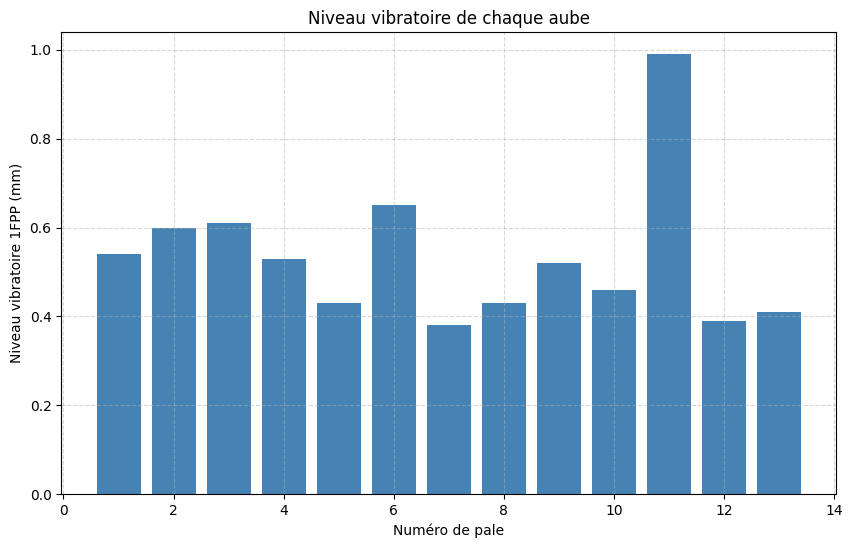

In [7]:
vib = vibrations.copy()

# Conversion des nombres écrits avec des virgules
vib['Niveau vibratoire 1FPP (mm)'] = vibrations['Niveau vibratoire 1FPP (mm)'].str.replace(',', '.').astype(float)

# Vérification
display(vib.head())

# 2.1 Bar plot du niveau vibratoire
plt.figure(figsize=(10, 6))
plt.bar(vib['N° Pale'], vib['Niveau vibratoire 1FPP (mm)'], color='steelblue')
plt.title("Niveau vibratoire de chaque aube")
plt.xlabel("Numéro de pale")
plt.ylabel("Niveau vibratoire 1FPP (mm)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


### 2.2 Analyse par ACP de l'importance des variables géométriques

On dispose d'un grand nombre de variables géométriques (111 variables). On souhaite déterminer quelles sont les variables géométriques importantes en analysant leurs poids dans les composantes principales du jeu de données.

#### 2.2.1 Effectuez une ACP sur le jeu de données géométriques, puis calculez et visualisez la part de variance expliquée par chaque composante principale. Interprétez le résultat. Quelle part de variance est expliquée par les 2 premières CP ?

In [8]:
from sklearn.decomposition import PCA

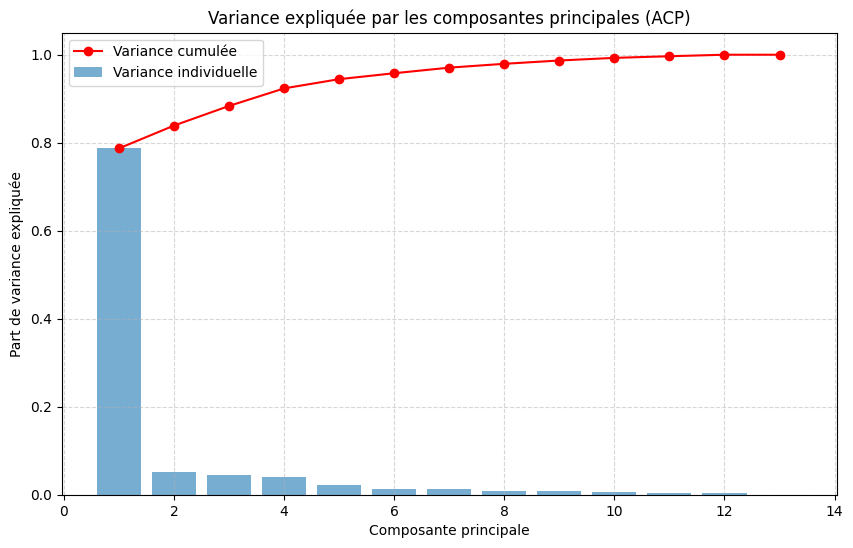

Les deux premières composantes principales expliquent environ 83.90% de la variance totale.


In [9]:
# On utilise les variables géométriques standardisées
X = geom_scaled_df  # obtenu à l'étape 1.2

# 1️⃣ Application de l'ACP
pca = PCA()
X_pca = pca.fit_transform(X)

# 2️⃣ Variance expliquée par composante
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# 3️⃣ Visualisation de la variance expliquée
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_var) + 1), explained_var, alpha=0.6, label="Variance individuelle")
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o', color='red', label="Variance cumulée")
plt.title("Variance expliquée par les composantes principales (ACP)")
plt.xlabel("Composante principale")
plt.ylabel("Part de variance expliquée")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 4️⃣ Affichage de la part de variance expliquée par les 2 premières composantes
var_2_first = cumulative_var[1] * 100
print(f"Les deux premières composantes principales expliquent environ {var_2_first:.2f}% de la variance totale.")


Une technique très courante pour analyser l'importance des variables est de visualiser leurs poids dans le plan des 2 premières composantes principales.

#### 2.2.2 Visualisez le poids des variables géométriques dans le plan (PC1, PC2)

**Indice 1 :** utilisez pour cela les composantes des vecteurs principaux de la matrice `pca.components_`.

**Indice 2 :** Afin d'obtenir une graphique avec une bonne échelle entre -1 et 1, il est nécessaire d'appliquer aux poids de chaque composante principale un facteur d'échelle égal à $\sqrt{\text{variance expliquée}}$.

Voici le type de graphique, appelé _PCA factor loadings plot_ en anglais, que vous devriez obtenir :

<img src="./rc/pca-plot.png" height=500px width=500px />

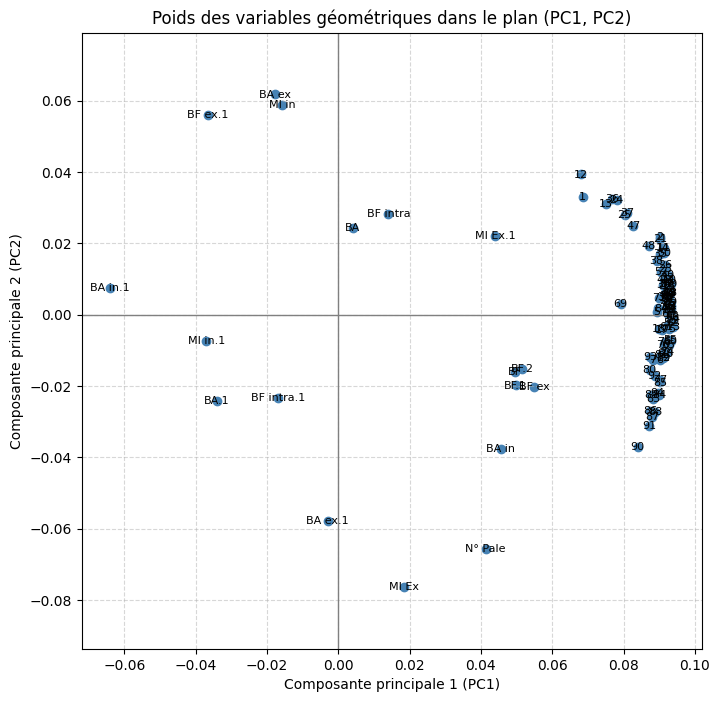

In [10]:
# Récupération des noms des variables
features = geom_scaled_df.columns

# Récupération des composantes principales et du facteur d'échelle
pcs = pca.components_  # composantes principales
explained_var = pca.explained_variance_ratio_

# Facteur d’échelle pour chaque axe
scaling_factors = np.sqrt(explained_var[:2])

# Application du facteur d’échelle aux poids des variables
weights = pcs[:2, :].T * scaling_factors

# Création du graphique
plt.figure(figsize=(8, 8))
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)

# Affichage des points (chaque variable)
plt.scatter(weights[:, 0], weights[:, 1], color='steelblue')

# Annotation du nom des variables
for i, var in enumerate(features):
    plt.text(weights[i, 0], weights[i, 1], var, fontsize=8, ha='center', va='center')

plt.title("Poids des variables géométriques dans le plan (PC1, PC2)")
plt.xlabel("Composante principale 1 (PC1)")
plt.ylabel("Composante principale 2 (PC2)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.show()


#### 2.2.3 Interprétez le graphique précédent. Quelles sont les variables géométriques les plus importantes ?

Les variables d'épaisseurs (numérotées de 1 à 94) sont toutes situées dans la partie la plus à droite du plan des composantes principales. Elles ont donc un poids très important sur la PC1, beaucoup plus que les autres variables géométriques. Étant donné que la PC1 représente presque 80% de la variance, on peut en conclure que les variables d'épaisseurs sont les plus importantes.

## 3. Identification de l'aube anormale par analyse des corrélations

Suite aux analyses précédentes, on décide de se focaliser sur les variables géométriques correspondant aux épaisseurs de l'aube (variables 1-94). Par ailleurs, les experts mécaniciens nous ont informés que les vibrations étaient corrélées à l'épaisseur de l'aube en différentes points. Par conséquent, nous pouvons décrire les données géométriques en utilisant **seulement la première composante principale** : on se ramène donc à un cas **univarié**, avec une seule variable $\text{PC1}$ (projection sur la première composante principale).

**Objectif :** trouver la permutation circulaire des numérotations d'aubes qui **maximise** la corrélation entre vibrations et épaisseurs des aubes, afin d'identifier l'aube défectueuse.

Voici 3 coefficients de corrélation usuels permettant de mesurer l'association de deux variables (ici, $X =\text{PC1} $ et $Y = \text{vibration}$) :

Coefficient de corrélation | formule | lien wikipédia
---------------------------|----------|---------------
Corrélation de Pearson     | $\rho(X, Y) = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}$ | https://fr.wikipedia.org/wiki/Corr%C3%A9lation_(statistiques)
Corrélation de Spearman    | $\rho_S(X, Y) = \frac{\text{Cov}(\text{rank}(X), \text{rank}(Y))}{\sigma_{\text{rank}_X} \sigma_{\text{rank}(Y)}}$ | https://fr.wikipedia.org/wiki/Corr%C3%A9lation_de_Spearman
Corrélation de Kendall     | $\tau(X, Y) = \frac{2\sum_{i<j}\text{sign}(x_j-x_i)\text{sign}(y_j-y_i)}{N(N-1)}$ | https://fr.wikipedia.org/wiki/Tau_de_Kendall


### 3.1 Quel(s) coefficient(s) vous semble(nt) adapté(s) pour analyser les corrélations entre nos variables ?

Dans notre cas, les variables X=PC1 et Y=vibration sont continues mais peuvent présenter une relation non parfaitement linéaire et un faible nombre d’observations.
Les coefficients de Spearman et de Kendall sont donc les plus adaptés pour analyser la corrélation, car ils mesurent la relation monotone et sont robustes aux valeurs extrêmes.
Le coefficient de Pearson peut toutefois être utilisé en complément pour estimer la linéarité de la relation.

### 3.2 Calculez les corrélations pour les 12 décalages circulaires possibles entre les données géométriques et les vibrations. Visualisez-les sur un graphique.

**Indice :** on peut facilement obtenir une permuation circulaire d'un jeu de données à l'aide de la fonction `numpy.roll(...)`.

<div style="color: #1111bb; font-size: 16px; background-color: #eeeeff; padding: 20px; border-radius: 15px">
    <p><b>Rappel :</b> On n'utilise que la PC1 des variables géométriques !</p>
</div>

Il est recommandé de calculer les _$p$-values_ associées au coefficient de corrélation choisi. Ces valeurs permettent de déterminer si les corrélations trouvées sont **significatives ou non**. La $p$-value est associée aux deux hypothèses statistiques suivantes :

* $\mathcal{H}_0$ : les variables X et Y sont indépendantes (pas de corrélation)
* $\mathcal{H}_1$ : les variables X et Y sont dépendantes (corrélation)

La $p$-value correspond à la **probabilité de se tromper en rejetant l'hypothèse null $\mathcal{H}_0$**. On fait généralement le choix de rejeter l'hypothèse nulle lorsque $p$-value < 0.05, i.e. moins de 5% de chances de se tromper.

In [11]:
import math
def kendall_tau(x, y):
    """Compute Kendall's tau correlation
    
    Arguments
        xs : float array (n)
            input variable 1
        ys : float array (n)
        input variable 2
        
    Returns
        tau : float in [-1, 1]
            correlation coefficient
        pvalue : float
            p-value
    """
    assert x.size == y.size
    size = x.size
    
    tot = (size * (size-1)) // 2
    s = np.array([np.sign(x[j] - x[i]) * np.sign(y[j] - y[i]) for j in range(size) for i in range(j)])
    tau = np.sum(s) / tot
    
    dis = np.sum(s < 0)  # number of discordant pairs
    # Exact p-value, see Maurice G. Kendall, "Rank Correlation Methods" (4th Edition), Charles Griffin & Co., 1970.
    c = min(dis, tot-dis)
    if size <= 0:
        raise ValueError
    elif c < 0 or 2*c > size*(size-1):
        raise ValueError
    elif size == 1:
        pvalue = 1.0
    elif size == 2:
        pvalue = 1.0
    elif c == 0:
        pvalue = 2.0/math.factorial(size) if size < 171 else 0.0
    elif c == 1:
        pvalue = 2.0/math.factorial(size-1) if (size-1) < 171 else 0.0
    else:
        new = [0.0]*(c+1)
        new[0] = 1.0
        new[1] = 1.0
        for j in range(3,size+1):
            old = new[:]
            for k in range(1,min(j,c+1)):
                new[k] += new[k-1]
            for k in range(j,c+1):
                new[k] += new[k-1] - old[k-j]
        pvalue = 2.0*sum(new)/math.factorial(size) if size < 171 else 0.0
        
    return tau, pvalue

PC1 shape: (13,), vibration shape: (13,)


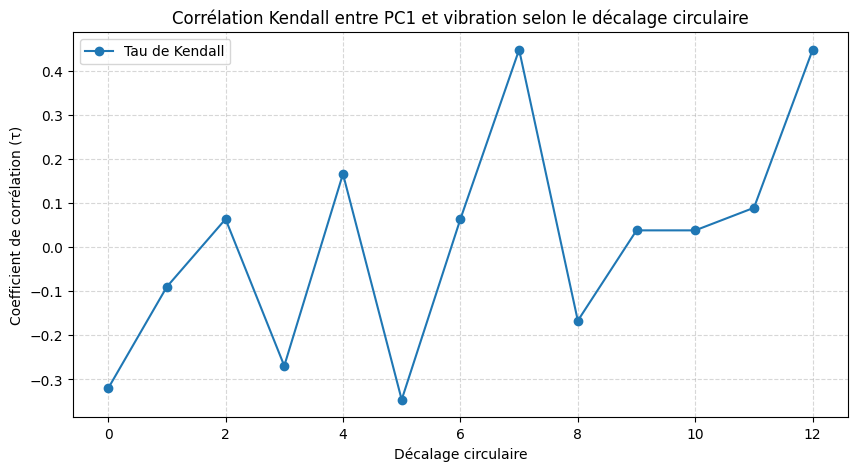

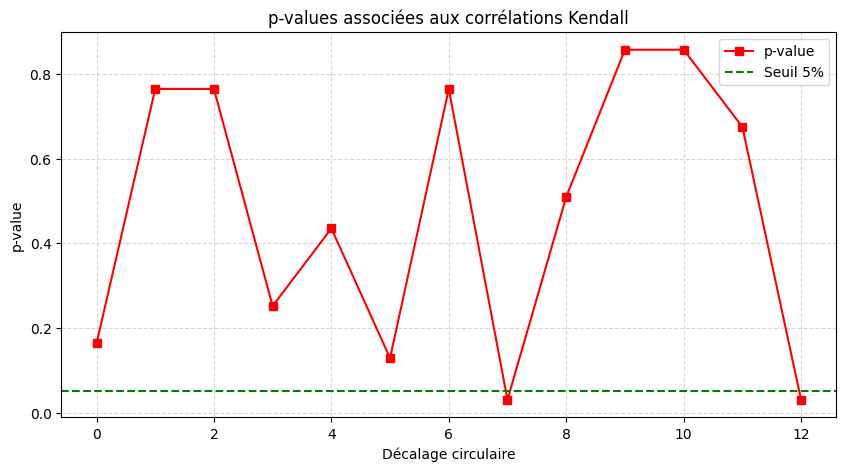

Décalage circulaire maximal : 7
Corrélation max = 0.449, p-value = 3.048e-02


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr, kendalltau

# 1️⃣ Extraction de la première composante principale (PC1)
PC1 = X_pca[:, 0]   # première composante du PCA (déjà calculée précédemment)
vibration = vib['Niveau vibratoire 1FPP (mm)'].values  # variable vibratoire

# Vérif de taille
print(f"PC1 shape: {PC1.shape}, vibration shape: {vibration.shape}")

# 2️⃣ Calcul des corrélations pour tous les décalages circulaires
corrs = []
pvals = []
decalages = range(len(vibration))  # 0 à 13

for d in decalages:
    vib_shifted = np.roll(vibration, d)  # décalage circulaire
    tau, p = kendall_tau(PC1, vib_shifted)  # fonction donnée dans l’énoncé
    corrs.append(tau)
    pvals.append(p)

# 3️⃣ Visualisation des corrélations
plt.figure(figsize=(10, 5))
plt.plot(decalages, corrs, marker='o', label="Tau de Kendall")
plt.title("Corrélation Kendall entre PC1 et vibration selon le décalage circulaire")
plt.xlabel("Décalage circulaire")
plt.ylabel("Coefficient de corrélation (τ)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 4️⃣ Visualisation des p-values
plt.figure(figsize=(10, 5))
plt.plot(decalages, pvals, marker='s', color='red', label="p-value")
plt.axhline(0.05, color='green', linestyle='--', label="Seuil 5%")
plt.title("p-values associées aux corrélations Kendall")
plt.xlabel("Décalage circulaire")
plt.ylabel("p-value")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 5️⃣ Identifier le décalage optimal
best_shift = np.argmax(np.abs(corrs))
print(f"Décalage circulaire maximal : {best_shift}")
print(f"Corrélation max = {corrs[best_shift]:.3f}, p-value = {pvals[best_shift]:.3e}")


### 3.3 Quel est le décalage circulaire qui maximise la corrélation ? (il peut éventuellement en y avoir plusieurs) Peut-on en déduire l'aube anormale ?

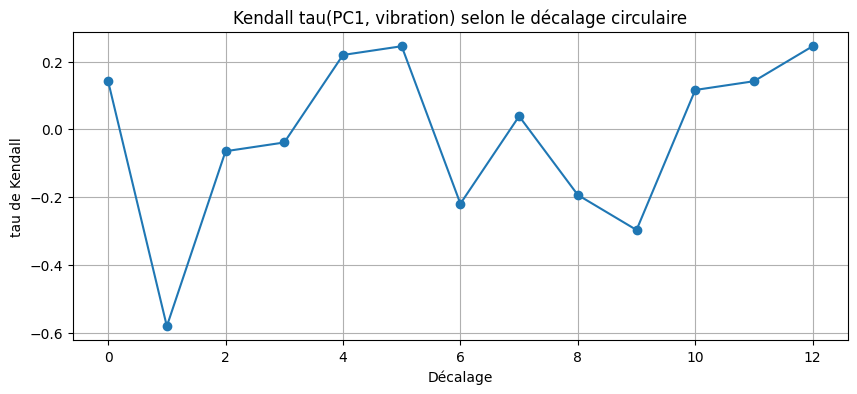

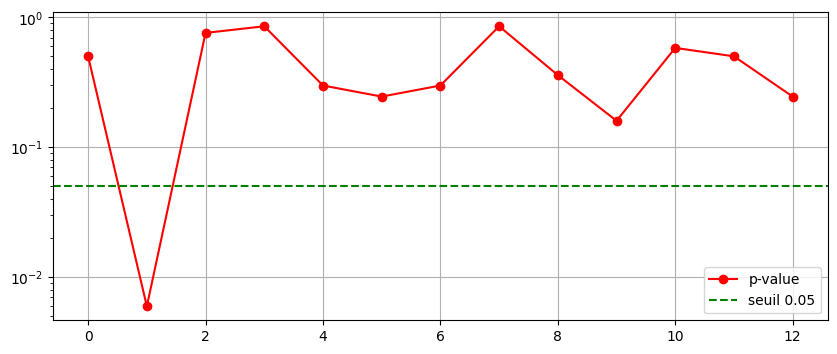

([1], [-0.5806572458540727], [0.00595001136492636])

In [13]:
from sklearn.impute import SimpleImputer

# === 3.3 - Corrélation Kendall pour les 12 décalages circulaires ===
geom_raw = pd.read_csv("./data/Rouet_geometries.csv", encoding='latin', sep=';', header=0)
geom = geom_raw.copy()
for c in geom.columns:
    geom[c] = geom[c].astype(str).str.replace(',', '.')
    geom[c] = pd.to_numeric(geom[c], errors='coerce')

numeric_cols = geom.select_dtypes(include=[np.number]).columns.tolist()
thickness_cols = numeric_cols[:94]
X_thick = geom[thickness_cols].values

# Imputation et standardisation
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_thick)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


pca = PCA()
X_pca = pca.fit_transform(X_scaled)
PC1 = X_pca[:, 0]
n = min(len(PC1), len(vibration))
PC1 = PC1[:n]
vibration = vibration[:n]


shifts = list(range(n))
taus = []
pvals = []

for d in shifts:
    vib_shift = np.roll(vibration, d)
    tau, p = kendalltau(PC1, vib_shift)
    taus.append(float(tau))
    pvals.append(float(p))

plt.figure(figsize=(10,4))
plt.plot(shifts, taus, marker='o')
plt.title("Kendall tau(PC1, vibration) selon le décalage circulaire")
plt.xlabel("Décalage")
plt.ylabel("tau de Kendall")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(shifts, pvals, marker='o', color='red', label='p-value')
plt.axhline(0.05, color='green', linestyle='--', label='seuil 0.05')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

best_shifts = [i for i,t in enumerate(taus) if abs(t) == max(abs(np.array(taus)))]
best_shifts, [taus[i] for i in best_shifts], [pvals[i] for i in best_shifts]

Le décalage circulaire qui maximise la corrélation entre PC1 et la vibration est 1 (tau = -0.581, p = 0.00595). C’est statistiquement significatif, donc il y a bien un alignement entre PC1 et vibration pour ce décalage.

### 3.4 L'analyse de la PC1 ne s'est pas révélée suffisante, une analyse plus fine est nécessaire. Calculez, pour chaque décalage circulaire de la numérotation des aubes, les corrélations entre toutes les variables d'épaisseur (94 variables) et le niveau vibratoire. Concluez sur l'identité de l'aube défaillante, ainsi que sur la zone précise du défaut.

Utilisation de 94 colonnes d'épaisseur (nombres).
Alignement sur n = 13 observations.


,shift,best_var_index,best_var_name,best_spearman,best_pvalue
0,0,3,Unnamed: 3,0.488952,0.089958
1,1,40,Unnamed: 40,0.745530,0.003441
2,2,5,Unnamed: 5,-0.424828,0.147891
3,3,17,Unnamed: 17,-0.468201,0.106614
4,4,86,Unnamed: 86,-0.528926,0.063092
5,5,80,Unnamed: 80,-0.466853,0.107763
6,6,14,Unnamed: 14,-0.568752,0.042523
7,7,6,Unnamed: 6,-0.768710,0.002136
8,8,93,Unnamed: 93,0.654270,0.015260
9,9,7,Unnamed: 7,-0.642463,0.017885



Meilleur couple global (max |Spearman|) :
{'shift': 7, 'var_index': 6, 'var_name': 'Unnamed: 6', 'spearman': -0.7687098582079157, 'pvalue': 0.0021362616910563406}

Pale suspecte selon variable Unnamed: 6: 12
Z-score (abs) = 2.028, valeur = 0.0700


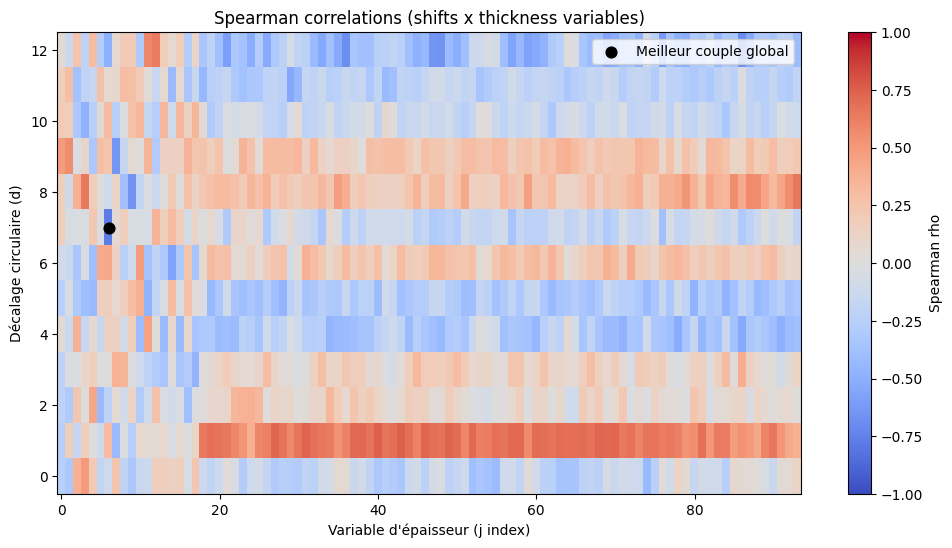

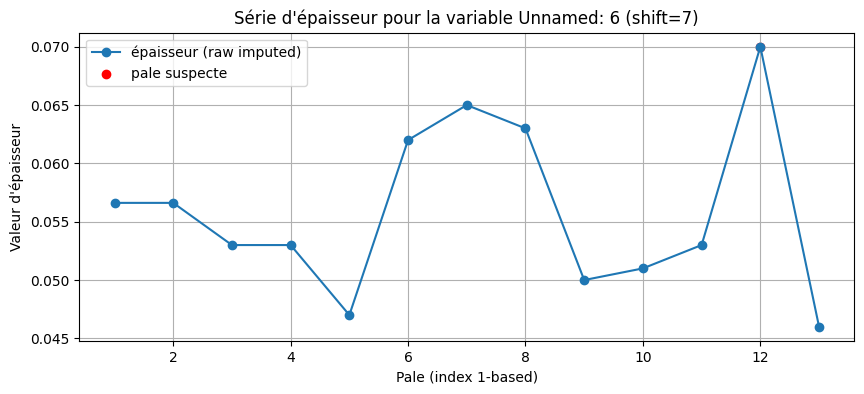

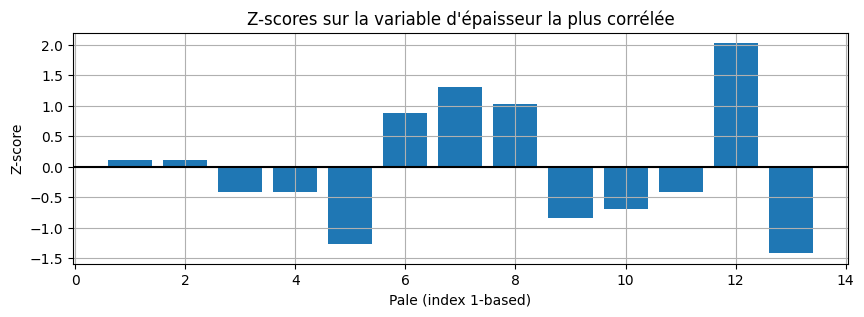

In [14]:
# 3.4 Exécution complète : corrélations variables d'épaisseur (94) vs vibration pour chaque décalage

# sélectionner les 94 premières colonnes numériques
numeric_cols = geom.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) < 1:
    raise RuntimeError("Aucune colonne numérique trouvée dans geom.")
thickness_cols = numeric_cols[:94] if len(numeric_cols) >= 94 else numeric_cols
m = len(thickness_cols)
print(f"Utilisation de {m} colonnes d'épaisseur (nombres).")

# matrice raw (après imputation)
X_thick = geom[thickness_cols].values
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_thick)   # shape (n_obs, m)

# standardisation (gardée si besoin)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# alignement longueur n = min(#obs, #vibrations)
n = min(X_imputed.shape[0], vibration.shape[0])
X_imputed = X_imputed[:n, :]
X_scaled = X_scaled[:n, :]
vibration = vibration[:n]
print(f"Alignement sur n = {n} observations.")

# Pré-allocation matrices de corrélations et p-values (shifts x variables)
shifts = list(range(n))
corrs = np.zeros((n, m))
pvals = np.ones((n, m))

# Calcul Spearman pour chaque shift et variable (on utilise les séries raw imputées)
for d in shifts:
    vib_shift = np.roll(vibration, d)
    for j in range(m):
        col = X_imputed[:, j]
        rs, p = spearmanr(col, vib_shift)
        # si nan -> mettre 0
        corrs[d, j] = 0.0 if np.isnan(rs) else float(rs)
        pvals[d, j] = 1.0 if np.isnan(p) else float(p)

# Pour chaque shift, trouver la variable j qui maximise |Spearman|
best_per_shift = []
for d in shifts:
    j_best = int(np.nanargmax(np.abs(corrs[d, :])))
    best_per_shift.append({
        'shift': d,
        'best_var_index': j_best,
        'best_var_name': thickness_cols[j_best],
        'best_spearman': float(corrs[d, j_best]),
        'best_pvalue': float(pvals[d, j_best])
    })
best_df = pd.DataFrame(best_per_shift)
display(best_df)

# Identifier le meilleur couple global (selon |Spearman|)
abs_vals = np.abs(corrs)
idx_flat = np.nanargmax(abs_vals)
d_global, j_global = divmod(idx_flat, m)
global_best = {
    'shift': int(d_global),
    'var_index': int(j_global),
    'var_name': thickness_cols[j_global],
    'spearman': float(corrs[d_global, j_global]),
    'pvalue': float(pvals[d_global, j_global])
}
print("\nMeilleur couple global (max |Spearman|) :")
print(global_best)

# Pour la variable j_global, examiner la série d'épaisseur et identifier la pale suspecte
thickness_series = X_imputed[:, j_global]  # raw imputed values for that variable
mean_val = np.nanmean(thickness_series)
std_val = np.nanstd(thickness_series, ddof=0)
z_scores = (thickness_series - mean_val) / (std_val if std_val != 0 else 1.0)
suspect_idx = int(np.nanargmax(np.abs(z_scores)))
# essayer de récupérer numéro de pale si présent
pale_id_col = None
for possible in ['N° Pale', 'No Pale', 'Pale', 'Aube', 'Num', 'Index']:
    if possible in vibrations.columns:
        pale_id_col = possible
        break

if pale_id_col is None and 'N° Pale' in geom.columns:
    pale_id_col = 'N° Pale'

if pale_id_col is not None:
    suspect_pale_label = vibrations[pale_id_col].values[:n][suspect_idx]
else:
    suspect_pale_label = f"index {suspect_idx} (1-based: {suspect_idx+1})"

print(f"\nPale suspecte selon variable {global_best['var_name']}: {suspect_pale_label}")
print(f"Z-score (abs) = {abs(z_scores[suspect_idx]):.3f}, valeur = {thickness_series[suspect_idx]:.4f}")

# Visualisation : heatmap des corrélations (shifts x variables)
plt.figure(figsize=(12,6))
plt.imshow(corrs, aspect='auto', origin='lower', cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Spearman rho')
plt.xlabel('Variable d\'épaisseur (j index)')
plt.ylabel('Décalage circulaire (d)')
plt.title('Spearman correlations (shifts x thickness variables)')
plt.scatter([j_global], [d_global], color='black', s=60, label='Meilleur couple global')
plt.legend()
plt.show()

# Plot de la série d'épaisseur et z-scores pour la variable gagnante
plt.figure(figsize=(10,4))
plt.plot(range(1, n+1), thickness_series, marker='o', label='épaisseur (raw imputed)')
plt.scatter(suspect_idx+1, thickness_series[suspect_idx], color='red', label='pale suspecte')
plt.xlabel('Pale (index 1-based)')
plt.ylabel('Valeur d\'épaisseur')
plt.title(f"Série d'épaisseur pour la variable {global_best['var_name']} (shift={global_best['shift']})")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,3))
plt.bar(range(1, n+1), z_scores)
plt.axhline(0, color='k')
plt.xlabel('Pale (index 1-based)')
plt.ylabel('Z-score')
plt.title('Z-scores sur la variable d\'épaisseur la plus corrélée')
plt.grid(True)
plt.show()

**En analysant toutes les 94 variables :**

* Le meilleur alignement global (selon |Spearman|) est obtenu pour le décalage 7 et la variable 'Unnamed: 6' (index 6).

* La pale suspecte sur cette variable est la pale 12 (z ≈ 2.03), ce qui localise précisément la zone du défaut (la position correspondante le long de la pale mesurée par la variable Unnamed: 6).